This notebook explores historical retail demand to identify patterns, seasonality, pricing effects, and operational insights that will inform feature engineering and model development.
- How does demand change over time?
- Which stores generate the highest demand?
- Which product categories contribute most to sales?
- How do prices affect demand?
- What role do holidays and SNAP events play?
- Which patterns should be incorporated into the forecasting model?

In [1]:
from src.utils.project_setup import *

from src.data.loader import load_master_data

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
master = load_master_data()

master.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,Saturday,1,1,2011,NaN,NaN,NaN,NaN,0,0,0,NaN


In [5]:
master.shape

(58327370, 22)

In [6]:
master.info()

<class 'pandas.DataFrame'>
RangeIndex: 58327370 entries, 0 to 58327369
Data columns (total 22 columns):
 #   Column        Dtype  
---  ------        -----  
 0   id            str    
 1   item_id       str    
 2   dept_id       str    
 3   cat_id        str    
 4   store_id      str    
 5   state_id      str    
 6   d             str    
 7   sales         int64  
 8   date          str    
 9   wm_yr_wk      int64  
 10  weekday       str    
 11  wday          int64  
 12  month         int64  
 13  year          int64  
 14  event_name_1  str    
 15  event_type_1  str    
 16  event_name_2  str    
 17  event_type_2  str    
 18  snap_CA       int64  
 19  snap_TX       int64  
 20  snap_WI       int64  
 21  sell_price    float64
dtypes: float64(1), int64(8), str(13)
memory usage: 14.3 GB


In [7]:
master.describe().T

,count,mean,std,min,25%,50%,75%,max
sales,58327370.0,1.126322,3.873108,0.00,0.00,0.00,1.00,763.00
wm_yr_wk,58327370.0,11339.191323,150.374182,11101.00,11217.00,11333.00,11448.00,11613.00
wday,58327370.0,3.997386,2.000652,1.00,2.00,4.00,6.00,7.00
month,58327370.0,6.357554,3.458773,1.00,3.00,6.00,9.00,12.00
year,58327370.0,2013.209096,1.532086,2011.00,2012.00,2013.00,2015.00,2016.00
snap_CA,58327370.0,0.329326,0.469968,0.00,0.00,0.00,1.00,1.00
snap_TX,58327370.0,0.329326,0.469968,0.00,0.00,0.00,1.00,1.00
snap_WI,58327370.0,0.329326,0.469968,0.00,0.00,0.00,1.00,1.00
sell_price,46027957.0,4.408089,3.403657,0.01,2.18,3.47,5.84,107.32


In [8]:
master.isna().sum().sort_values(ascending=False)

event_type_2    58205410
event_name_2    58205410
event_type_1    53631910
event_name_1    53631910
sell_price      12299413
id                     0
state_id               0
store_id               0
cat_id                 0
dept_id                0
item_id                0
d                      0
date                   0
sales                  0
year                   0
month                  0
wday                   0
weekday                0
wm_yr_wk               0
snap_CA                0
snap_TX                0
snap_WI                0
dtype: int64

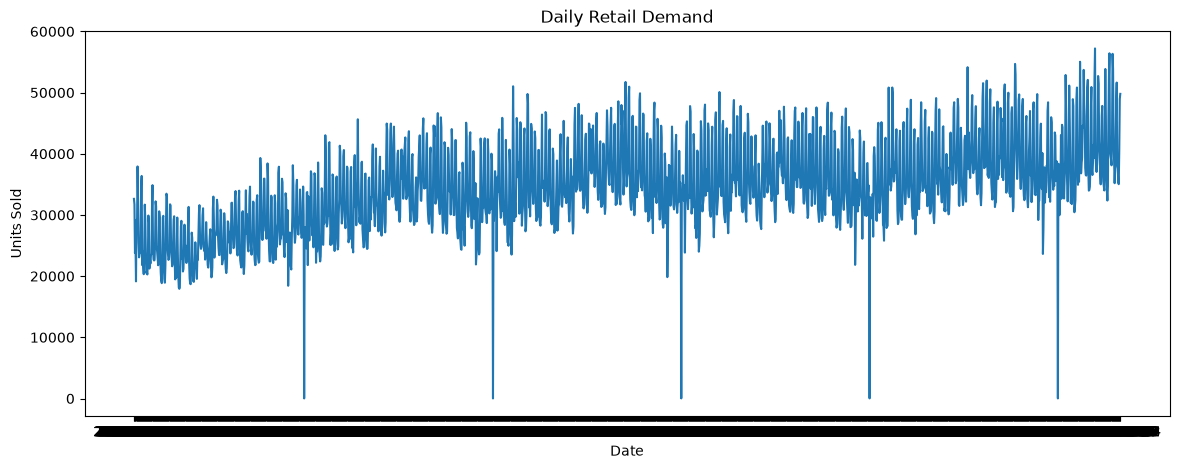

In [9]:
daily_sales = (
    master.groupby("date")["sales"]
          .sum()
)

plt.figure(figsize=(14,5))
plt.plot(daily_sales)
plt.title("Daily Retail Demand")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()

Daily demand fluctuates throughout the observation period, suggesting recurring seasonal patterns and short-term variability.

These trends indicate that historical demand contains information that can be leveraged for forecasting.

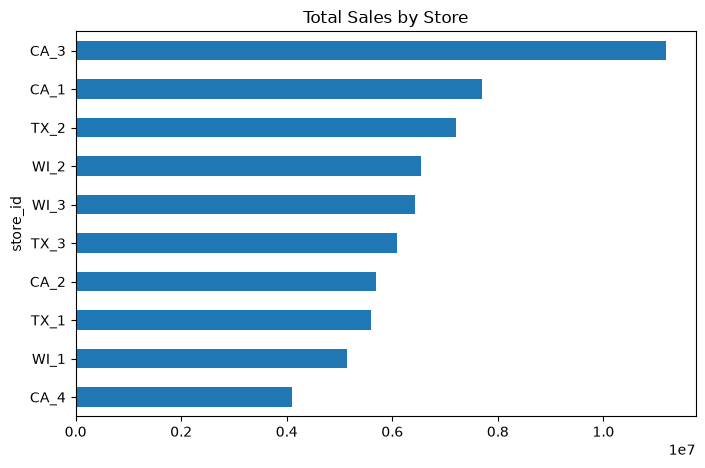

In [10]:
store_sales = (
    master.groupby("store_id")["sales"]
          .sum()
          .sort_values()
)

plt.figure(figsize=(8,5))
store_sales.plot(kind="barh")
plt.title("Total Sales by Store")
plt.show()

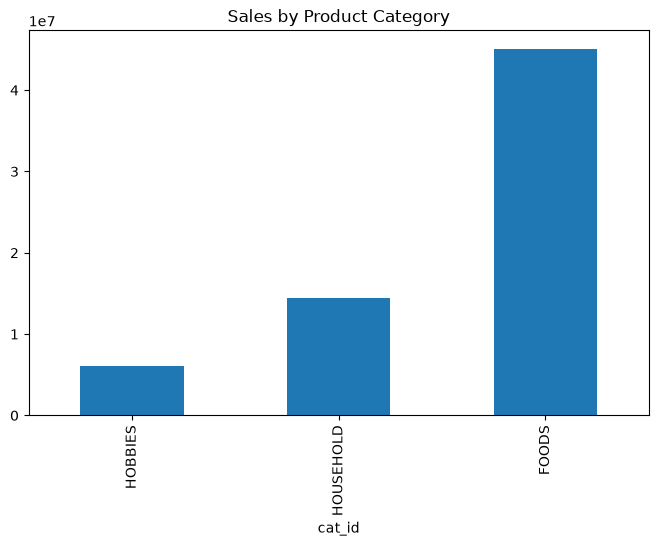

In [11]:
category_sales = (
    master.groupby("cat_id")["sales"]
          .sum()
          .sort_values()
)

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")
plt.title("Sales by Product Category")
plt.show()

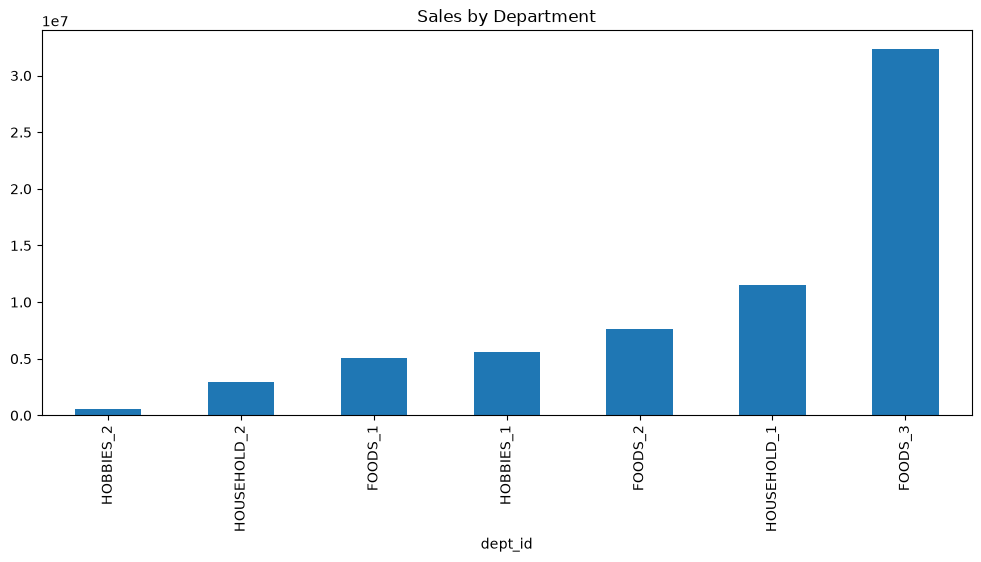

In [12]:
dept_sales = (
    master.groupby("dept_id")["sales"]
          .sum()
          .sort_values()
)

plt.figure(figsize=(12,5))
dept_sales.plot(kind="bar")
plt.title("Sales by Department")
plt.show()

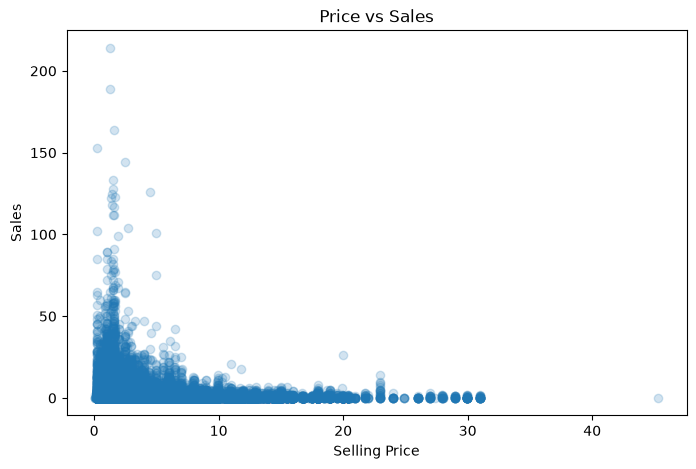

In [13]:
sample = master.sample(100000, random_state=42)

plt.figure(figsize=(8,5))
plt.scatter(
    sample["sell_price"],
    sample["sales"],
    alpha=0.2
)
plt.xlabel("Selling Price")
plt.ylabel("Sales")
plt.title("Price vs Sales")
plt.show()

The relationship between price and demand appears non-linear.

Tree-based machine learning models are well suited to capturing these complex interactions.

In [14]:
snap_sales = (
    master.groupby("snap_CA")["sales"]
          .mean()
)

snap_sales

snap_CA
0    1.095720
1    1.188643
Name: sales, dtype: float64

In [15]:
snap_sales = (
    master.groupby("snap_TX")["sales"]
          .mean()
)

snap_sales

snap_TX
0    1.090948
1    1.198361
Name: sales, dtype: float64

In [16]:
snap_sales = (
    master.groupby("snap_WI")["sales"]
          .mean()
)

snap_sales

snap_WI
0    1.090185
1    1.199916
Name: sales, dtype: float64

Average demand differs between SNAP and non-SNAP days, suggesting these indicators may improve forecasting accuracy.

In [17]:
missing = (
    master.isna()
          .sum()
          .sort_values(ascending=False)
)

missing.head(10)

event_type_2    58205410
event_name_2    58205410
event_type_1    53631910
event_name_1    53631910
sell_price      12299413
id                     0
state_id               0
store_id               0
cat_id                 0
dept_id                0
dtype: int64

In [19]:
# Percentage of missing prices
print(master["sell_price"].isna().mean() * 100)

# Sales records with missing prices
master.loc[
    master["sell_price"].isna(),
    ["store_id", "item_id", "wm_yr_wk", "sales"]
].head()

21.08686367994991


,store_id,item_id,wm_yr_wk,sales
0,CA_1,HOBBIES_1_001,11101,0
1,CA_1,HOBBIES_1_002,11101,0
2,CA_1,HOBBIES_1_003,11101,0
3,CA_1,HOBBIES_1_004,11101,0
4,CA_1,HOBBIES_1_005,11101,0


In [20]:
missing_price = master[master["sell_price"].isna()]

(
    missing_price["sales"] == 0
).mean()

np.float64(1.0)

Approximately 21.1% of observations have a missing selling price.
Every one of those observations has zero unit sales.
Therefore, the missing prices occur when no transaction took place.

# Findings

Key observations from exploratory analysis include:

- Retail demand exhibits clear variation.
- Demand differs across stores and product categories.
- Selling prices vary substantially across products.
- Calendar events influence purchasing behaviour.
- SNAP indicators may contribute predictive value.
- These findings support the creation of lag, rolling average, calendar, and pricing features in the next stage of the project.